# Eksperyment Imagenette - Porównanie Embeddingów z Treningiem na Wagach Places365
Ten notatnik wykonuje kurację danych poprzez hierarchical k-means na ekstrakcji cech z ResNet50 (Places365) oraz DINO.
**Kluczowa zmiana:** Ewaluacja podzbiorów (Linear Probing) dokonywana jest na zamrożonych wagach modelu ResNet50-Places365, a nie standardowego ResNet50 (ImageNet).

In [40]:
import os
import sys
import subprocess
import random
import warnings
import urllib.request
import tarfile
import shutil

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# --- SETUP ----
DEBUG = False
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", message=".*Torch was not compiled with flash attention.*")
# mps: macOS GPU support
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
SEED = 45390
PROJECT_PATH = os.path.abspath(os.path.join("."))
print(f"Device: {device}")

# --- CONFIG ---
REPO_NAME = "ssl-data-curation"
REPO_URL = "https://github.com/facebookresearch/ssl-data-curation.git"
REPO_PATH = os.path.join(os.getcwd(), f"{REPO_NAME}/")

DATA_URL = "https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-320.tgz"
DATA_DIR = "imagenette2-320"
DATA_PATH = os.path.abspath(os.path.join(os.getcwd(), f"{DATA_DIR}/"))
DATASET = "imagenette" # also supported: "skewed_imagenet1k" (loads from DATA_PATH), will support "places365" in the future
CLUSTERING_METHODS = ["hierarchical_sampling"] # other methods to be added (kmeans, dbscan, etc.)

# TRAINING PARAMETERS
NUM_CLASSES = 10        # or 20 for skewed datasets
MAX_EPOCHS = 50 
EARLY_STOPPING_PATIENCE = 5 
lr = 1e-2
batch_size = 64

# HIERARCHICAL SAMPLING PARAMETERS
N_CLUSTERS_DINO=[100, 10]
N_LEVELS_DINO=2
SAMPLE_SIZES_DINO=[65, 650]

N_CLUSTERS_RESNET=[100, 10]
N_LEVELS_RESNET=2
SAMPLE_SIZES_RESNET=[65, 650]

# OTHER CLASTERING METHODS PARAMETERS
N_CLUSTERS_KMEANS = 100
EPS_DBSCAN = 0.5
MIN_SAMPLES_DBSCAN = 5 

Device: cuda


In [41]:
def setup_repo():
    if not os.path.exists(REPO_PATH):
        print(f"--- Cloning repository {REPO_NAME}... ---")
        subprocess.run(["git", "clone", REPO_URL], check=True)

    src_path = os.path.join(REPO_PATH, "src")
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print("--- Repository paths configured ---")


def reorganize_places(path):
    # 1. Download the class map
    map_url = "https://raw.githubusercontent.com/CSAILVision/places365/master/places365_val.txt"
    map_path = "val_map.txt"
    urllib.request.urlretrieve(map_url, map_path)
    
    # 2. Create class folders and move files
    with open(map_path, 'r') as f:
        for line in f:
            img_name, class_idx = line.strip().split()
            # You can map class_idx to the actual name if you download categories.txt
            class_dir = os.path.join(path, "train", class_idx)
            os.makedirs(class_dir, exist_ok=True)
            shutil.move(os.path.join(path, img_name), os.path.join(class_dir, img_name))


def prepare_data(dataset=DATASET):
    if dataset == "imagenette":
        url = "https://s3.amazonaws.com/fast-ai-imagequant/imagenette2-320.tgz"
        filename = "imagenette.tgz"
    elif dataset == "places365":
        # 1.1 GB version (Validation set used as a proxy)
        url = "http://data.csail.mit.edu/places/places365/val_256.tar"
        filename = "places365_val.tar"
    else: return

    if not os.path.exists(DATA_PATH):
        if not os.path.exists(filename):
            print(f"--- Downloading {dataset} ---")
            urllib.request.urlretrieve(url, filename)
        
        mode = "r:gz" if filename.endswith(".tgz") else "r:"
        with tarfile.open(filename, mode) as tar:
            tar.extractall(path=PROJECT_PATH)
        
        if dataset == "places365":
            reorganize_places(DATA_PATH)
        print(f"--- {dataset} ready ---")

# Call it for any dataset
prepare_data()
        

if DATASET != "skewed_imagenet1k":     #otherwise, files will be loaded from dir specified in DATA_PATH
    prepare_data()

setup_repo()

from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs

--- Repository paths configured ---


In [42]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ----------------- TRANSFORMS & DATASETS ----------------------
class ResnetTransform:
    def __init__(self):
        self.transfrom = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    def __call__(self,img):
        return self.transfrom(img)

class DinoTransform:
    def __init__(self, processor=AutoImageProcessor.from_pretrained('facebook/dinov2-large')):
        self.processor = processor
    def __call__(self, img):
        return self.processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0)
    
train_dataset = datasets.ImageFolder(os.path.join(DATA_PATH,"train"), transform=ResnetTransform())

if DATASET == "imagenette":
    # need to manually split the test and validation sets, as the original dataset only contains train and val folders
    test_dataset = datasets.ImageFolder(os.path.join(DATA_PATH,"val"), transform=ResnetTransform())
    # Extract indices and labels
    indices = np.arange(len(test_dataset))
    labels = test_dataset.targets 

    # Split indices 50/50 with stratification
    v_idx, t_idx = train_test_split(
        indices, 
        test_size=0.5, 
        stratify=labels, 
        random_state=SEED
    )

    # Wrap indices in Subsets
    val_dataset = Subset(test_dataset, v_idx)
    test_dataset = Subset(test_dataset, t_idx)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

elif DATASET == "skewed_imagenet1k":
    
    test_dataset = datasets.ImageFolder(os.path.join(DATA_PATH,"test"), transform=ResnetTransform())
    val_dataset = datasets.ImageFolder(os.path.join(DATA_PATH,"val"), transform=ResnetTransform())
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# TODO: add loading for places365
elif DATASET == "places365":
    pass 
    

train_dataset_dino = datasets.ImageFolder(os.path.join(DATA_PATH,"train"), transform=DinoTransform())

In [43]:
# ----------------- PLACES365 WEIGHTS LOADER ----------------------
_PLACES_365_WEIGHTS_URL = (
    "http://places2.csail.mit.edu/models_places365/{model_id}_places365.pth.tar"
)
def _load_places_365_state_dict(model_id: str, device: torch.device) -> dict[str, torch.Tensor]:
    checkpoint = torch.hub.load_state_dict_from_url(
        _PLACES_365_WEIGHTS_URL.format(model_id=model_id),
        map_location=device,
    )
    state_dict = checkpoint["state_dict"]
    return {k.replace("module.", ""): v for k, v in state_dict.items()}

def get_places365_eval_model(num_classes, device):
    """
    Tworzy model ResNet50 zainicjowany wagami z Places365, 
    zamraża wagi konwolucyjne i ustawia głowę klasyfikacyjną na podaną liczbę klas.
    """
    model = models.resnet50()
    state_dict = _load_places_365_state_dict("resnet50", device)
    
    model.fc = nn.Linear(model.fc.in_features, 365)
    model.load_state_dict(state_dict)
    
    for params in model.parameters():
        params.requires_grad=False
        
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

# ----------------- EMBEDDING FUNCTIONS ----------------------
def get_dino_embedings(dataset, batch_size=128):
    extractor = AutoModel.from_pretrained('facebook/dinov2-large')
    extractor.eval()
    extractor.to(device)
    all_embedings = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        extr_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, _ in tqdm(extr_loader, desc="Dino Feature extraction"):
            imgs = imgs.to(device)
            outputs = extractor(imgs)
            embedings = outputs.last_hidden_state[:,0,:]
            all_embedings.append(embedings.cpu())
    return torch.cat(all_embedings).to(device)

def get_resnet50_places365_embedings(dataset, batch_size=128):
    extractor = models.resnet50()
    state_dict = _load_places_365_state_dict("resnet50", device)
    extractor.fc = nn.Linear(extractor.fc.in_features, 365)
    extractor.load_state_dict(state_dict)
    extractor.fc = nn.Identity()  # usunięcie głowy do ekstrakcji cech
    extractor.eval().to(device)
    
    all_features = []
    with torch.inference_mode(), torch.amp.autocast("cuda"):
        feature_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
        for imgs, _ in tqdm(feature_loader, desc="Places365 Feature extraction"):
            feat = extractor(imgs.to(device))
            all_features.append(feat.cpu())            
    return torch.cat(all_features).to(device)

In [44]:
# ----------------- TRAINING FUNCTION ----------------------
def train_model(model, criterion, optimizer, train_loader, val_dataloader, test_dataloader, device, title, max_epochs=MAX_EPOCHS,
                 epoch_tqdm=False, loader_tqdm=True, early_stopping=True, patience=EARLY_STOPPING_PATIENCE):
    print(f"\n[TRENING] Start: {title}")
    scaler = torch.amp.GradScaler("cuda")
    losses = []

    epoch_progress = range(max_epochs)
    if epoch_tqdm:
        epoch_progress = tqdm(range(max_epochs), desc='Epochs')
    patience_counter=0
    best_val_loss = np.inf
    best_state = model.state_dict()
    best_state = {k:v.clone() for k, v in best_state.items()}
    for epoch in epoch_progress:
        model.train()
        running_loss = 0.0
        loader_progress = train_loader
        if loader_tqdm:
            loader_progress = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}")
                                   
        for imgs, labels in loader_progress:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda"):
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
        losses.append(running_loss/len(train_loader))

        if early_stopping:
            model.eval()
            val_loss = 0.0
            with torch.inference_mode():
                for imgs, labels in val_dataloader:
                    imgs, labels = imgs.to(device), labels.to(device)
                    outputs = model(imgs)
                    val_loss += criterion(outputs, labels).item()
            val_loss = val_loss/len(val_dataloader)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict()
                best_state = {k:v.clone() for k, v in best_state.items()}
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break

    if early_stopping:
        model.load_state_dict(best_state)
    model.eval()
    
    correct = 0
    total = 0
    with torch.inference_mode():
        for loader, label in [(val_dataloader, "Validation"), (test_dataloader, "Test")]:
            for imgs, labels in loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total
            print(f"[RESULT] {title} {label} Accuracy: {accuracy:.2f}%")
    return accuracy, losses

In [45]:
import matplotlib.pyplot as plt

def plot_training_curve(losses, title="Training Curve"):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o', linestyle='-', color='b', label='Train Loss')
    
    plt.title(f"{title} - Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    plt.tight_layout()
    plt.show()


In [46]:
print("\n--- Feature extraction and hierarchical k-means (DINO) ---")
set_seed(SEED)
dino_embedings = get_dino_embedings(train_dataset_dino).float()
clusters_dino = hkmg.hierarchical_kmeans_with_resampling(
    data=dino_embedings,                                                                           
    n_clusters=N_CLUSTERS_DINO,
    n_levels=N_LEVELS_DINO,
    sample_sizes=SAMPLE_SIZES_DINO,
    verbose=False,
)
cl_dino = HierarchicalCluster.from_dict(clusters_dino)

print("\n--- Feature extraction and hierarchical k-means (ResNet-Places365) ---")
set_seed(SEED)
resnet_embedings = get_resnet50_places365_embedings(train_dataset).float()
clusters_places = hkmg.hierarchical_kmeans_with_resampling(
    data=resnet_embedings,                                                                           
    n_clusters=N_CLUSTERS_RESNET,
    n_levels=N_LEVELS_RESNET,
    sample_sizes=SAMPLE_SIZES_RESNET,
    verbose=False,
)
cl_places = HierarchicalCluster.from_dict(clusters_places)


--- Feature extraction and hierarchical k-means (DINO) ---


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Dino Feature extraction:   0%|          | 0/74 [00:00<?, ?it/s]

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  8.87it/s]

--- Feature extraction and hierarchical k-means (ResNet-Places365) ---


Places365 Feature extraction:   0%|          | 0/74 [00:00<?, ?it/s]

Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:01<00:00,  9.15it/s]


Experimenting with feature extraction for sampling | Dino vs Resnet50-Places365
Ewaluacja (Linear Probing) na wagach PLACES365
Subset size: 946 / 9469 (10.0%)

Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1788.84it/s]

[TRENING] Start: Dino features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping at epoch 11
[RESULT] Dino features | Validation Accuracy: 83.44%
[RESULT] Dino features | Test Accuracy: 83.62%


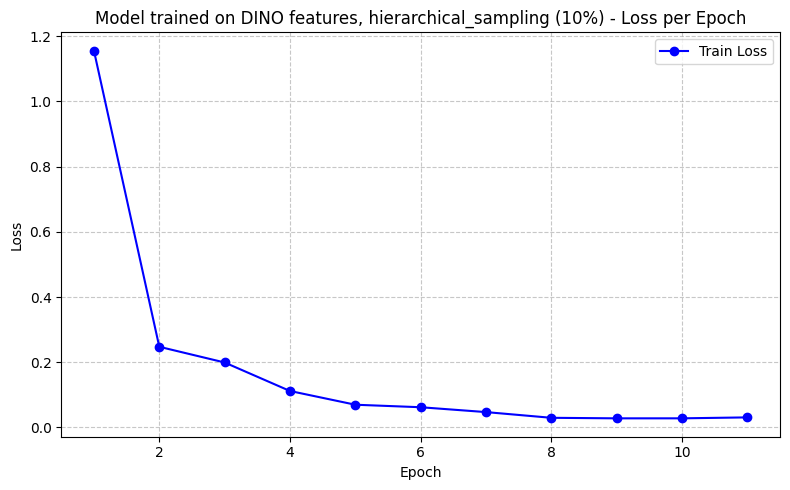


Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 1860.17it/s]

[TRENING] Start: Resnet-Places365 features |


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
from other_clustering_methods import kmeans_sampling, dbscan_sampling

print("Experimenting with feature extraction for sampling | Dino vs Resnet50-Places365")
print("Ewaluacja (Linear Probing) na wagach PLACES365")
print("="*60)


percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
results_embedings = pd.DataFrame(columns=["clustering_method","embedings", "percentage", "accuracy", "losses"])

for clustering_method in CLUSTERING_METHODS:
    for p in percentages:
        label = f"{int(p * 100)}%"
        target_size = int(len(train_dataset) * p)
        print(f"Subset size: {target_size} / {len(train_dataset)} ({p*100}%)")
        print()
        
        # -------------- trening modelu (LP, sampling z DINO) --------------------
        if p < 1.0:
            if clustering_method == "hierarchical_sampling":
                idx = hs.hierarchical_sampling(cl_dino, target_size=target_size)
            elif clustering_method == "kmeans":
                idx = kmeans_sampling(dino_embedings, target_size=target_size, n_clusters=100)
            elif clustering_method == "dbscan":
                idx = dbscan_sampling(dino_embedings, target_size=target_size, eps=0.5, min_samples=5)
            else:
                raise ValueError(f"Unknown clustering method: {clustering_method}")
            
            current_ds = Subset(train_dataset, idx)
        else:
            current_ds = train_dataset

        set_seed(SEED)
        # TWORZYMY MODEL RESNET50 Z WAGAMI PLACES365 DO EWALUACJI!
        model = get_places365_eval_model(NUM_CLASSES, device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        acc, losses = train_model(model, criterion, optimizer,
                                DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                        generator=torch.Generator().manual_seed(SEED)),
                                test_loader, val_loader, device,
                                "Dino features |",
                                max_epochs=MAX_EPOCHS, early_stopping=True, patience=EARLY_STOPPING_PATIENCE,
                                epoch_tqdm=True, loader_tqdm=False
                                )

        plot_training_curve(losses, title=f"Model trained on DINO features, {clustering_method} ({p*100:.0f}%)")
        embedings_name ="Dino"
        results_embedings.loc[len(results_embedings),] = {"clustering_method":clustering_method,'embedings':embedings_name, "percentage":label, "accuracy":acc, "losses":losses}
        print()
        
        # -------------- trening modelu (LP, sampling z Resnet-Places365) --------------------
        if p < 1.0:
            if clustering_method == "hierarchical_sampling":
                idx = hs.hierarchical_sampling(cl_places, target_size=target_size)
            elif clustering_method == "kmeans":
                idx = kmeans_sampling(resnet_embedings, target_size=target_size, n_clusters=100)
            elif clustering_method == "dbscan":
                idx = dbscan_sampling(resnet_embedings, target_size=target_size, eps=0.5, min_samples=5)
            else:
                raise ValueError(f"Unknown clustering method: {clustering_method}")
            current_ds = Subset(train_dataset, idx)
        else:
            current_ds = train_dataset

        set_seed(SEED)
        # TWORZYMY MODEL RESNET50 Z WAGAMI PLACES365 DO EWALUACJI!
        model = get_places365_eval_model(NUM_CLASSES, device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr = lr)
        acc, losses= train_model(model, criterion, optimizer,
                                DataLoader(current_ds, batch_size=batch_size, shuffle=True, num_workers=0,
                                        generator=torch.Generator().manual_seed(SEED)),
                                test_loader, val_loader, device,
                                "Resnet-Places365 features |",
                                max_epochs=MAX_EPOCHS, early_stopping=True, patience=EARLY_STOPPING_PATIENCE,
                                epoch_tqdm=True, loader_tqdm=False
                                )
        plot_training_curve(losses, title=f"Model trained on Resnet-Places365 features, {clustering_method} ({p*100:.0f}%)")
        embedings_name ="Resnet-Places365"
        results_embedings.loc[len(results_embedings),] = {"clustering_method":clustering_method,'embedings':embedings_name, "percentage":label, "accuracy":acc, "losses":losses}
        print()
        print("-"*60)
        print()

# save results to pkl for later evaluation and plotting
results_embedings.to_pickle("experiment_results.pkl")

# can later be loaded with:
# loaded_results = pd.read_pickle("experiment_results.pkl") --- IGNORE ---

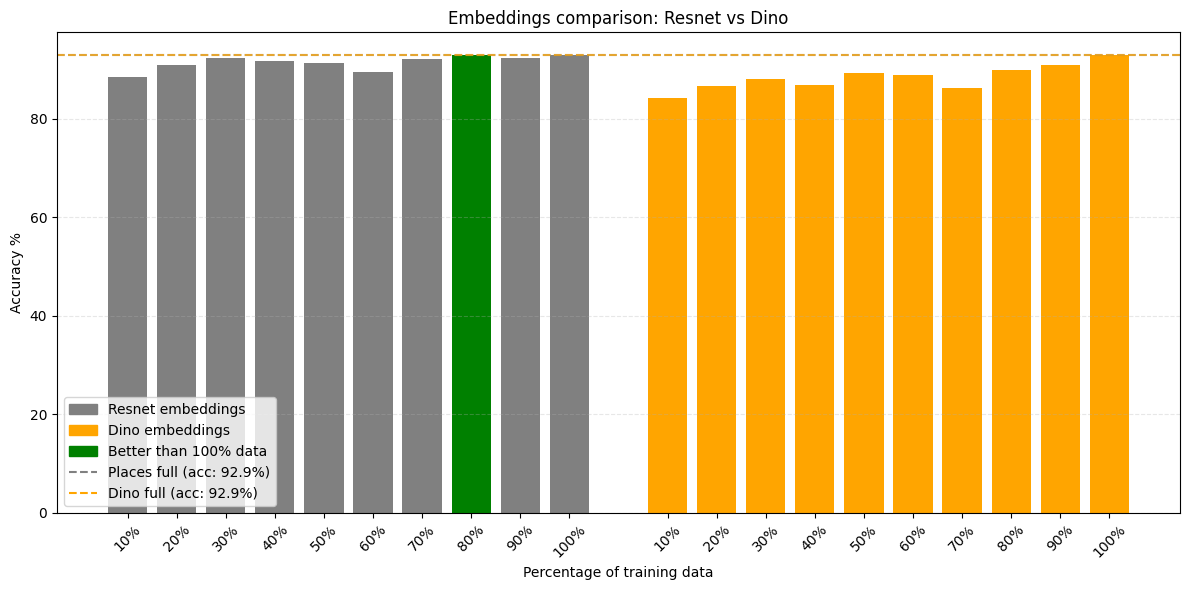

In [ ]:
# plt.figure(figsize=(12, 6))

# places = results_embedings[results_embedings["embedings"] == "Resnet-Places365"]
# dino = results_embedings[results_embedings["embedings"] == "Dino"]

# n = len(percentages)
# x_places = np.arange(n)
# x_dino = np.arange(n + 1, 2 * n + 1)

# places_full = places["accuracy"].values[-1]
# dino_full = dino["accuracy"].values[-1]

# places_colors = ['green' if a > places_full else 'gray' for a in places["accuracy"].values]
# dino_colors = ['green' if a > dino_full else 'orange' for a in dino["accuracy"].values]

# plt.bar(x_places, places["accuracy"].values, color=places_colors)
# plt.bar(x_dino, dino["accuracy"].values, color=dino_colors)

# plt.axhline(y=places_full, linestyle='--', color='gray', alpha=0.7)
# plt.axhline(y=dino_full, linestyle='--', color='orange', alpha=0.7)

# legend_handles = [
#     Patch(color='gray', label='Resnet embeddings'),
#     Patch(color='orange', label='Dino embeddings'),
#     Patch(color='green', label='Better than 100% data'),
#     Line2D([0], [0], linestyle='--', color='gray', label=f'Places full (acc: {places_full:.1f}%)'),
#     Line2D([0], [0], linestyle='--', color='orange', label=f'Dino full (acc: {dino_full:.1f}%)'),
# ]
# plt.legend(handles=legend_handles)

# all_x = np.concatenate([x_places, x_dino])
# all_labels = list(places["percentage"].values) + list(dino["percentage"].values)
# plt.xticks(all_x, all_labels, rotation=45)

# plt.xlabel('Percentage of training data')
# plt.ylabel('Accuracy %')
# plt.title('Embeddings comparison: Resnet vs Dino')
# plt.grid(axis='y', linestyle='--', alpha=0.3)
# plt.tight_layout()

# plt.show()